## Khai phá đồ thị - 2026

### Lab 05. Community detection.

Mục tiêu cuối cùng trong việc nghiên cứu các network là để hiểu rõ hơn về hành vi của các hệ thống mà chúng đại diện. 
- Chẳng hạn, ta nghiên cứu các mạng xã hội để hiểu rõ hơn về bản chất của các tương tác xã hội và tác động của chúng đối với trải nghiệm của con người, thương mại, sự lây lan của bệnh tật và cấu trúc của xã hội. 
- Ta nghiên cứu Internet để hiểu rõ hơn về luồng lưu lượng dữ liệu hoặc lý do tại sao các giao thức truyền thông hoạt động theo cách chúng hoạt động hoặc cách chúng tôi có thể thay đổi mạng để làm cho mạng hoạt động tốt hơn. 
- Ta nghiên cứu các mạng lưới sinh hóa giống như mạng lưới trao đổi chất vì ta hy vọng nó sẽ giúp hiểu rõ hơn về các quá trình hóa học phức tạp diễn ra trong tế bào và thậm chí có thể dẫn đến các liệu pháp mới cho bệnh tật hoặc chấn thương. 
Vấn đề tìm kiếm các nhóm node trong network được gọi là phát hiện cộng đồng (community detection). Mặc dù đơn giản để mô tả, phát hiện cộng đồng đây là một nhiệm vụ đầy thách thức, một số phương pháp đã được phát triển mang lại kết quả tốt trong các tình huống thực tế. 

Bên dưới đây là mô tả cách NetworkX có thể được sử dụng để phân tích các cộng đồng trong mạng.

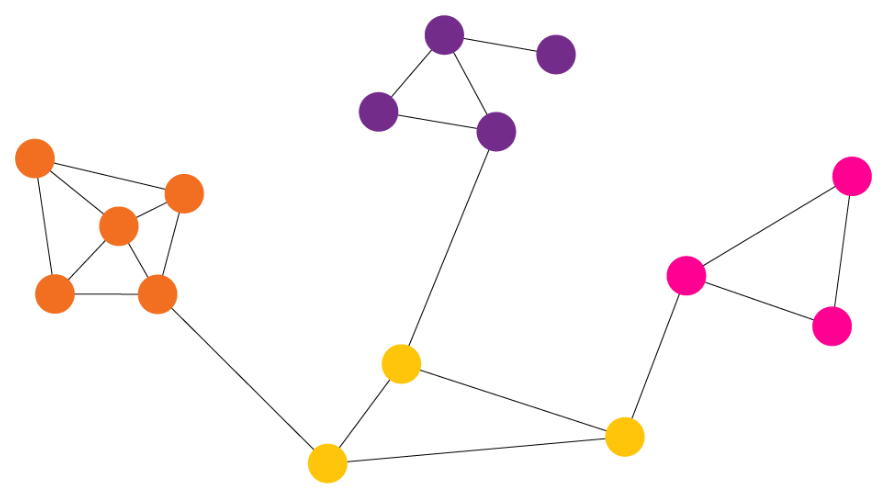

### 1. Mở đầu với graph Karate club.

Các cách trực tiếp nhất để biết có bao nhiêu cộng đồng trong một mạng là như sau:

In [11]:
import networkx as nx
import networkx.algorithms.community as nxcom
from matplotlib import pyplot as plt
%matplotlib inline
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.figsize': (15, 10)})
    # get reproducible results
import random
from numpy import random as nprand
random.seed(123)
nprand.seed(123)

In [12]:
G_karate = nx.karate_club_graph()

In [13]:
G1 = nx.complement(G_karate)

In [14]:
G_karate = nx.karate_club_graph()
# Find the communities
communities = sorted(nxcom.greedy_modularity_communities(G_karate), key=len, reverse=True)
# Count the communities
print(f"The karate club has {len(communities)} communities.")

The karate club has 3 communities.


Đầu ra của phát hiện cộng đồng bao gồm các tập hợp số đỉnh (tập hợp các tập hợp). Để có thể visualize, chúng ta cần thêm một số hàm như bên dưới.

In [15]:
def set_node_community(G, communities):
#'''Add community to node attributes'''
    for c, v_c in enumerate(communities):
        for v in v_c:
                # Add 1 to save 0 for external edges
            G.nodes[v]['community'] = c + 1
def set_edge_community(G):
#   '''Find internal edges and add their community to their attributes'''
    for v, w, in G.edges:
        if G.nodes[v]['community'] == G.nodes[w]['community']:
                # Internal edge, mark with community
            G.edges[v, w]['community'] = G.nodes[v]['community']
        else:
                # External edge, mark as 0
            G.edges[v, w]['community'] = 0
def get_color(i, r_off=1, g_off=1, b_off=1):
#    '''Assign a color to a vertex.'''
    r0, g0, b0 = 0, 0, 0
    n = 16
    low, high = 0.1, 0.9
    span = high - low
    r = low + span * (((i + r_off) * 3) % n) / (n - 1)
    g = low + span * (((i + g_off) * 5) % n) / (n - 1)
    b = low + span * (((i + b_off) * 7) % n) / (n - 1)
    return (r, g, b)

Với các hàm trên, ta đã có thể chỉ định thông tin cộng đồng cho các phần tử:

In [16]:
# Set node and edge communities
set_node_community(G_karate, communities)
set_edge_community(G_karate)
node_color = [get_color(G_karate.nodes[v]['community']) for v in G_karate.nodes]
    # Set community color for edges between members of the same community (internal) and intra-community edges (external)
external = [(v, w) for v, w in G_karate.edges if G_karate.edges[v, w]['community'] == 0]
internal = [(v, w) for v, w in G_karate.edges if G_karate.edges[v, w]['community'] > 0]
internal_color = ['black' for e in internal]

Và bên dưới là mô hình visualize:

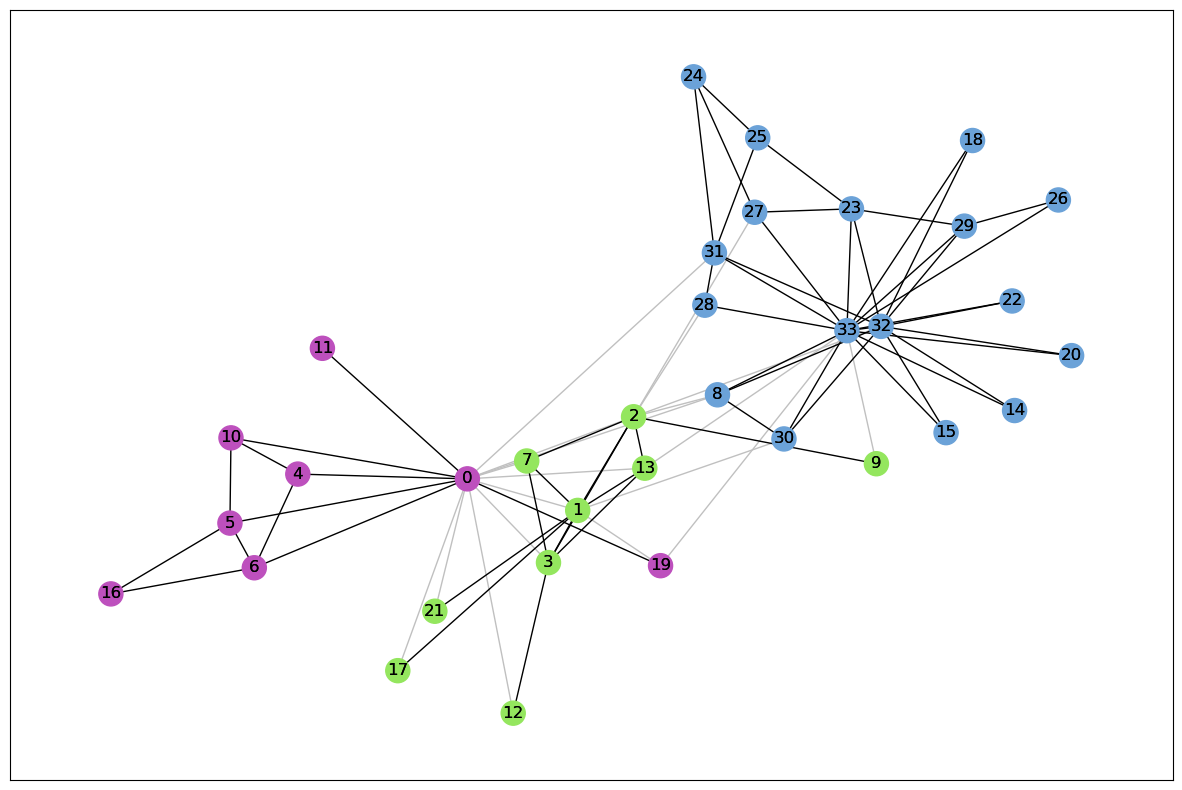

In [17]:
karate_pos = nx.spring_layout(G_karate)
plt.rcParams.update({'figure.figsize': (15, 10)})
    # Draw external edges
nx.draw_networkx(G_karate,pos=karate_pos,node_size=0,edgelist=external,edge_color="silver")
    # Draw nodes and internal edges
nx.draw_networkx(G_karate,pos=karate_pos,node_color=node_color,edgelist=internal,edge_color=internal_color)
plt.show()

### 2. Dữ liệu graph lớn hơn.

Dữ liệu lấy từ link sau đây: http://snap.stanford.edu/data/ego-Facebook.html, dựa vào đó, ta có thể có các thao tác tương tự (SV tải file facebook_combined.txt.gz về, giải nén ra và đặt cùng thư mục với file Lab này.

In [18]:
data_path = './facebook_combined.txt'
G_social = nx.read_edgelist(data_path)

PermissionError: [Errno 13] Permission denied: './facebook_combined.txt'

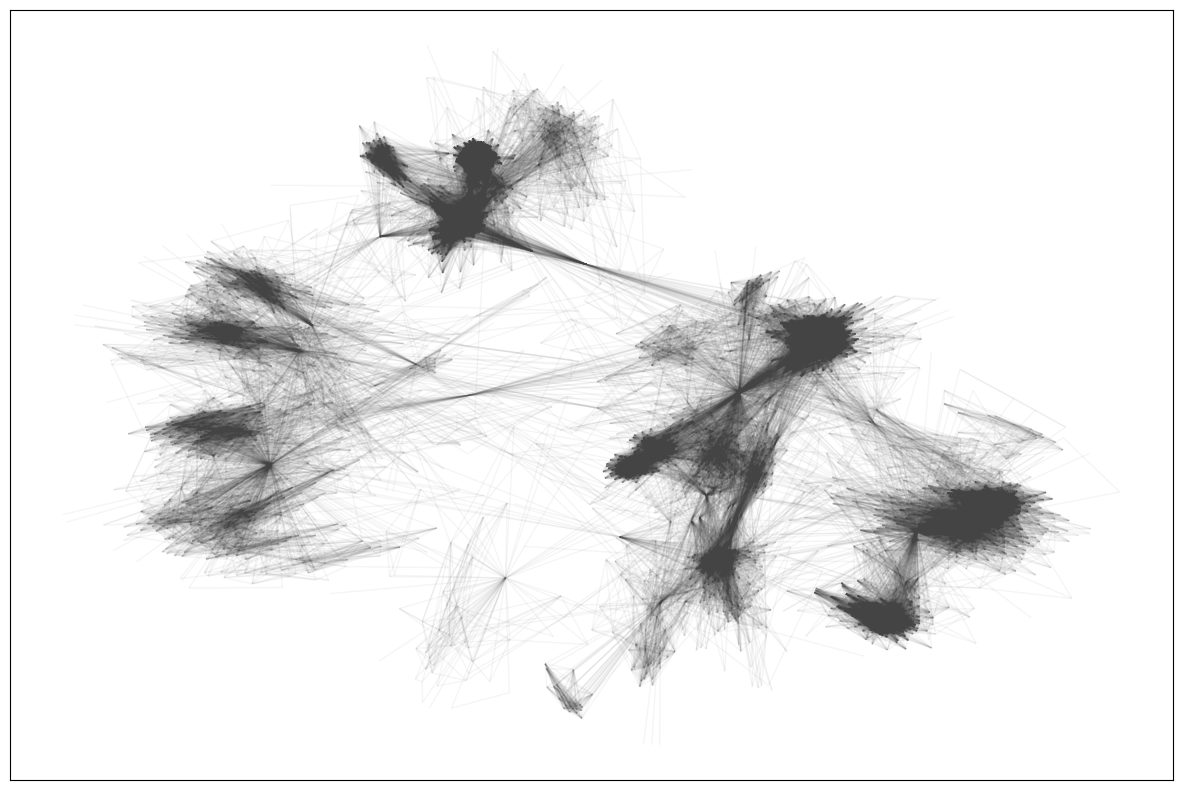

In [19]:
#cell này chạy khoảng 5 phút
pos = nx.spring_layout(G_social, k=0.1)
plt.rcParams.update({'figure.figsize': (15, 10)})
nx.draw_networkx(G_social,pos=pos,node_size=0,edge_color="#444444",alpha=0.05,with_labels=False)
plt.show()

In [20]:
communities = sorted(nxcom.greedy_modularity_communities(G_social), key=len, reverse=True)
len(communities)

13

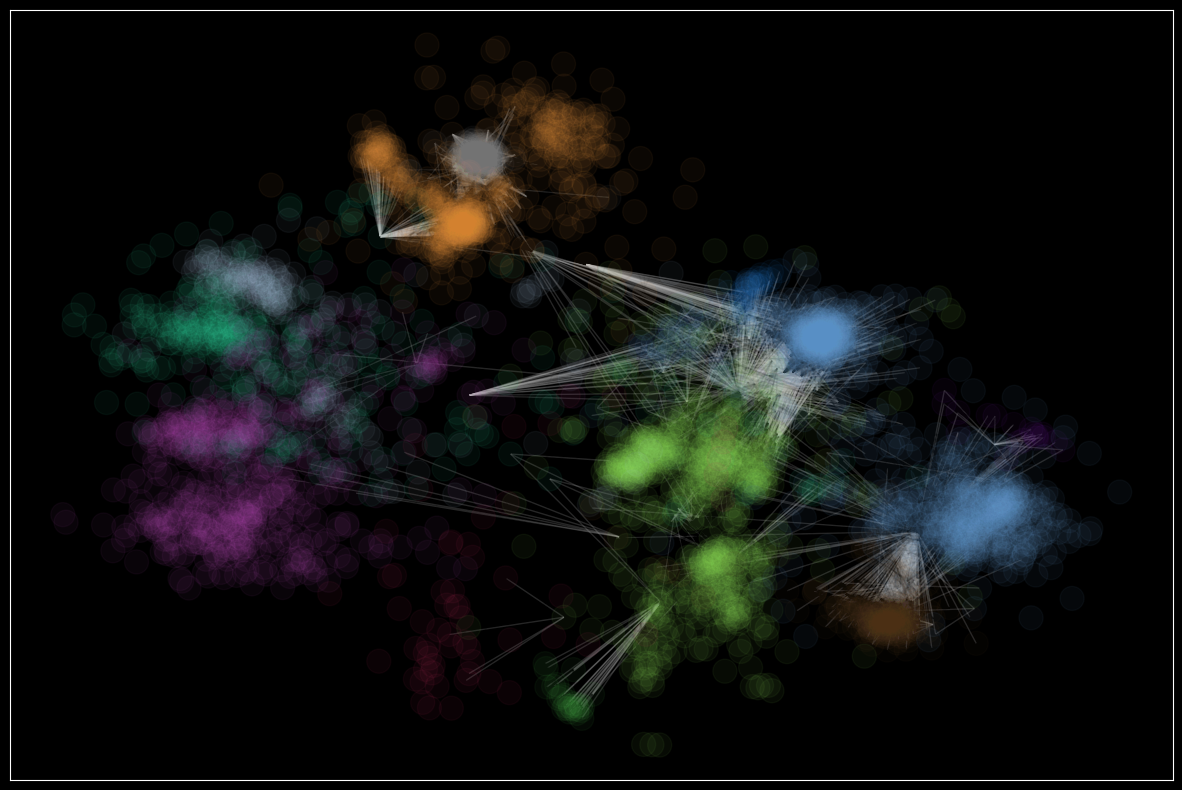

In [21]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.figsize': (15, 10)})
plt.style.use('dark_background')
    # Set node and edge communities
set_node_community(G_social, communities)
set_edge_community(G_social)
    # Set community color for internal edges
external = [(v, w) for v, w in G_social.edges if G_social.edges[v, w]['community'] == 0]
internal = [(v, w) for v, w in G_social.edges if G_social.edges[v, w]['community'] > 0]
internal_color = ["black" for e in internal]
node_color = [get_color(G_social.nodes[v]['community']) for v in G_social.nodes]
    # external edges
nx.draw_networkx(G_social,pos=pos,node_size=0,edgelist=external,edge_color="silver",node_color=node_color,alpha=0.2,
                 with_labels=False)
    # internal edges
nx.draw_networkx(G_social, pos=pos,edgelist=internal,edge_color=internal_color,node_color=node_color,alpha=0.05,
        with_labels=False)
plt.show()

### 3. Thuật toán Girvan–Newman.

Nhắc lại về betweeness centrality (độ trung gian).
Độ trung gian cho phép đo mức độ mà một node hoặc cạnh nằm trên các đường đi giữa các node khác. Các node và cạnh có độ trung gian cao có thể có ảnh hưởng đáng kể trong mạng dưới sự kiểm soát của chúng đối với thông tin truyền giữa các mạng khác. Để tính giá trị này, ta tính số đường đi ngắn nhất trong đồ thị đi qua node hoặc cạnh tương ứng rồi chia cho tổng số đường đi ngắn nhất.

Thuật toán Girvan–Newman phát hiện các cộng đồng bằng cách loại bỏ dần các cạnh khỏi mạng ban đầu. Các thành phần được kết nối của mạng còn lại là các cộng đồng. Thay vì cố gắng xây dựng một thước đo để có thể biết các cạnh nào là trung tâm nhất đối với các cộng đồng, thuật toán Girvan–Newman tập trung vào các cạnh có nhiều khả năng là "trung tâm" của các cộng đồng nhất.
Cụ thể là:

- For every edge in a graph, calculate the edge betweenness centrality.
- Remove the edge with the highest betweenness centrality.
- Calculate the betweenness centrality for every remaining edge.
- Repeat steps 2–4 until there are no more edges left.

In [46]:
#Mã giả.

#REPEAT
#    LET n BE number of edges in the graph
#    FOR i=0 to n-1
#        LET B[i] BE betweenness centrality of edge i
#        IF B[i] > max_B THEN
#            max_B = B[i]
#            max_B_edge = i
#        ENDIF
#    ENDFOR
#    REMOVE edge i FROM graph
#UNTIL number of edges in graph is 0

[[0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]]


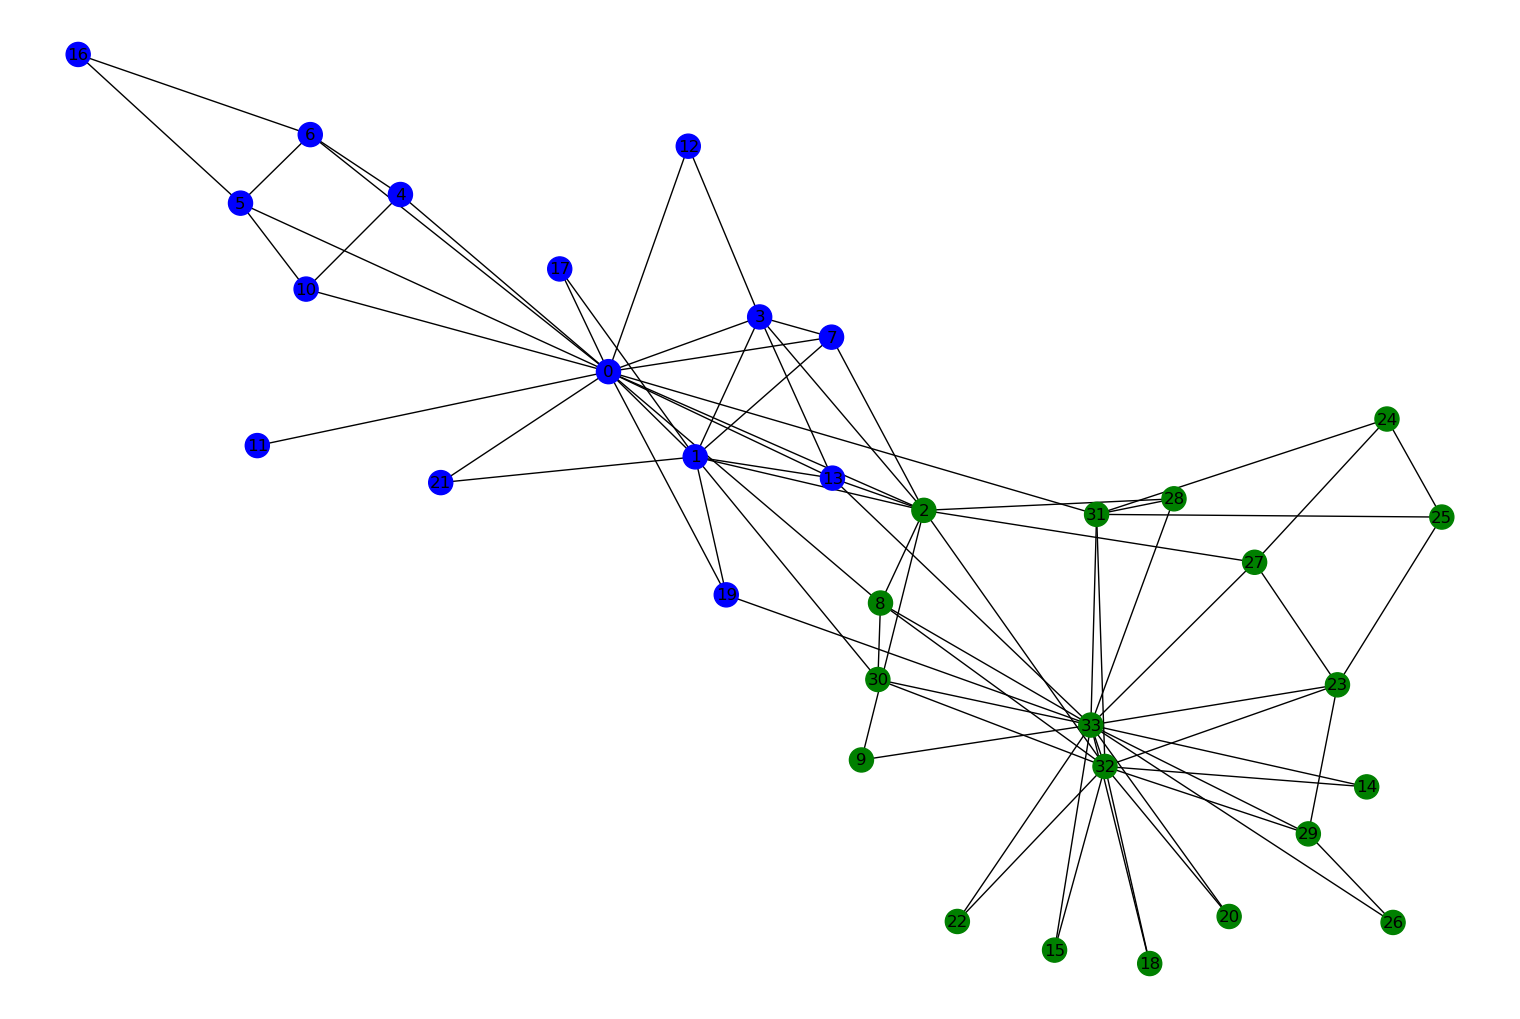

In [52]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community.centrality import girvan_newman
 
G = nx.karate_club_graph()
communities = girvan_newman(G)
 
node_groups = []
for com in next(communities):
      node_groups.append(list(com))
print(node_groups)
 
color_map = []
for node in G:
    if node in node_groups[0]:
        color_map.append('blue')
    else:
        color_map.append('green')
nx.draw(G, node_color=color_map, with_labels=True)
plt.show()

Dưới đây là một cách làm khác:

In [24]:
result = nxcom.girvan_newman(G_karate)
communities = next(result)
len(communities)

2

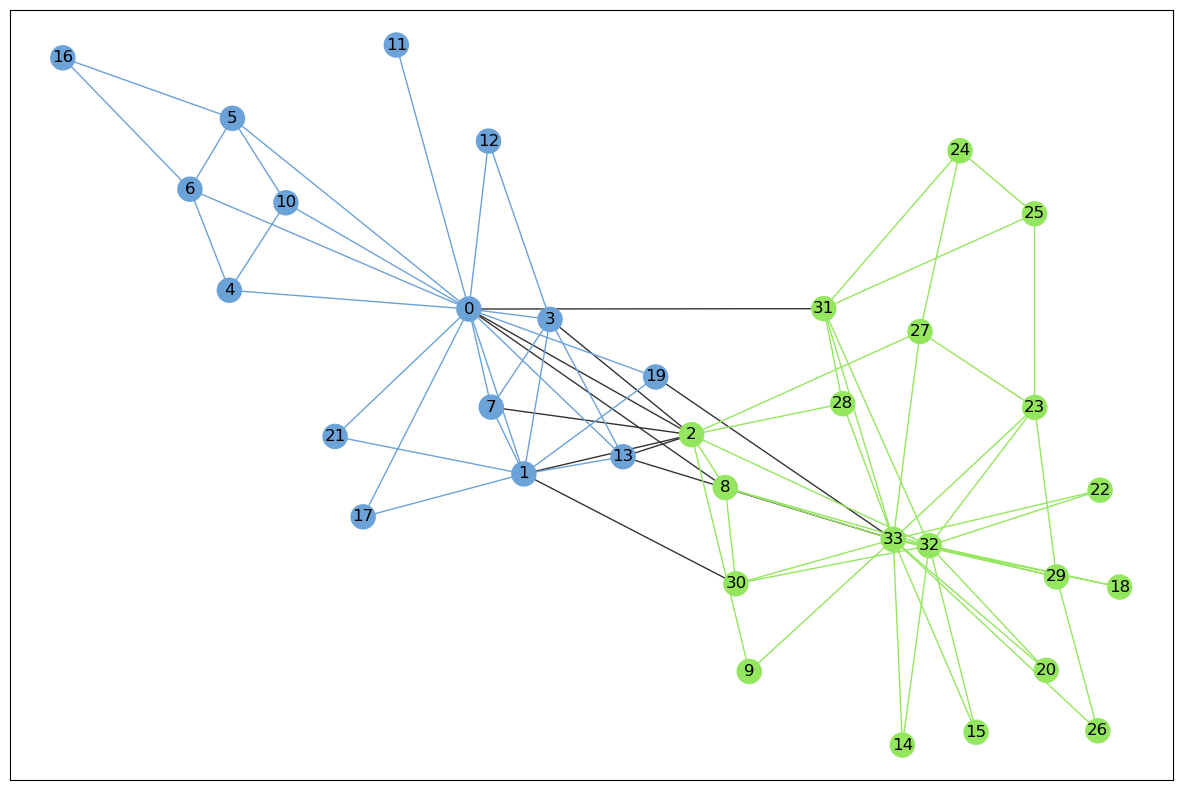

In [26]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.figsize': (15, 10)})
    # Set node and edge communities
set_node_community(G_karate, communities)
set_edge_community(G_karate)
    # Set community color for nodes
node_color = [get_color(G_karate.nodes[v]['community']) for v in G_karate.nodes]
    # Set community color for internal edges
external = [(v, w) for v, w in G_karate.edges if G_karate.edges[v, w]['community'] == 0]
internal = [(v, w) for v, w in G_karate.edges if G_karate.edges[v, w]['community'] > 0]
internal_color = [get_color(G_karate.edges[e]['community']) for e in internal]
karate_pos = nx.spring_layout(G_karate)
    # Draw external edges
nx.draw_networkx(G_karate, pos=karate_pos, node_size=0,
        edgelist=external, edge_color="#333333", with_labels=False)
# Draw nodes and internal edges
nx.draw_networkx(G_karate, pos=karate_pos, node_color=node_color,
        edgelist=internal, edge_color=internal_color)
plt.show()

### 4. Clique (graph con đầy đủ).

Một clique là một tập hợp con các đỉnh của graph vô hướng sao cho mọi hai đỉnh tùy ý trong đó đều kề nhau. Các nhóm theo một cách nào đó là các cộng đồng chặt chẽ, nơi mọi nút được kết nối với nhau. Hãy xem xét nhóm lớn nhất trong câu lạc bộ karate:

20


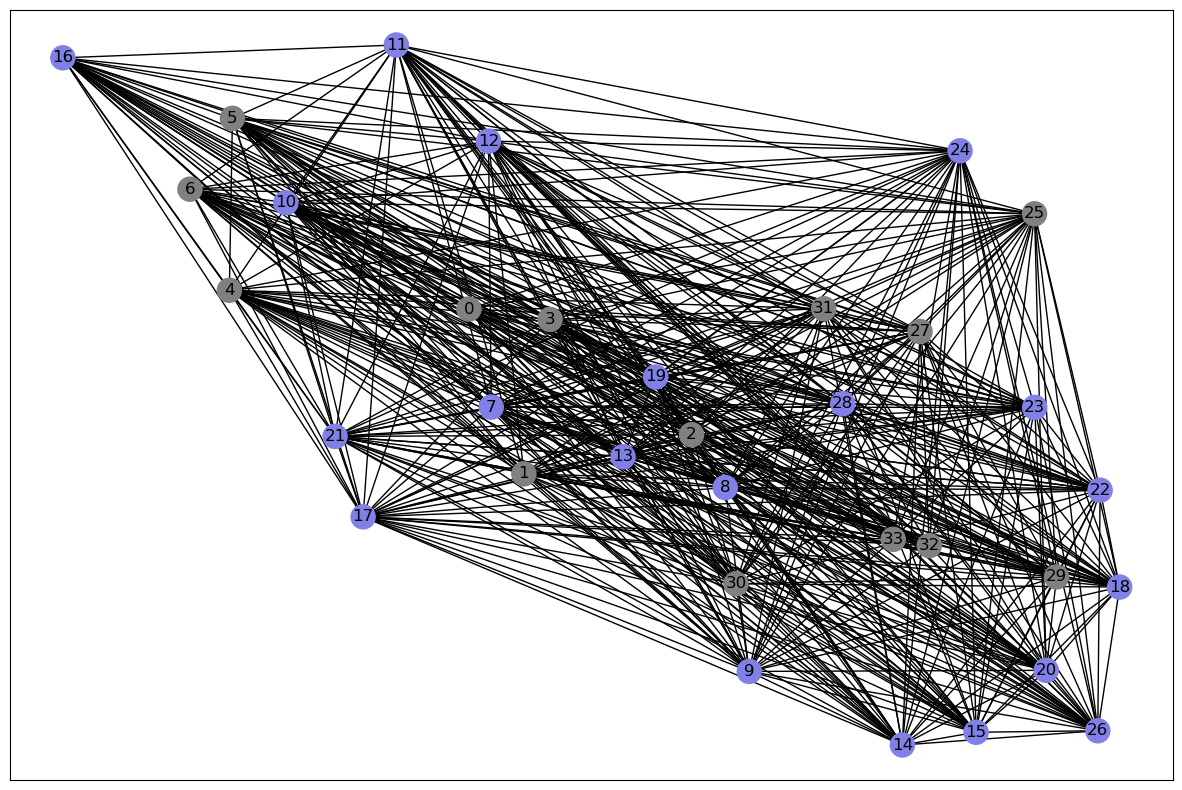

In [16]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.figsize': (15, 10)})
cliques = list(nx.find_cliques(G1))
max_clique = max(cliques, key=len)
node_color = [(0.5, 0.5, 0.5) for v in G1.nodes()]
for i, v in enumerate(G1.nodes()):
    if v in max_clique:
         node_color[i] = (0.5, 0.5, 0.9)
nx.draw_networkx(G1, node_color=node_color, pos=karate_pos)
print(len(max_clique))
plt.show()

In [17]:
nx.maximal_independent_set(G1)  

[3, 2, 0, 7, 1]

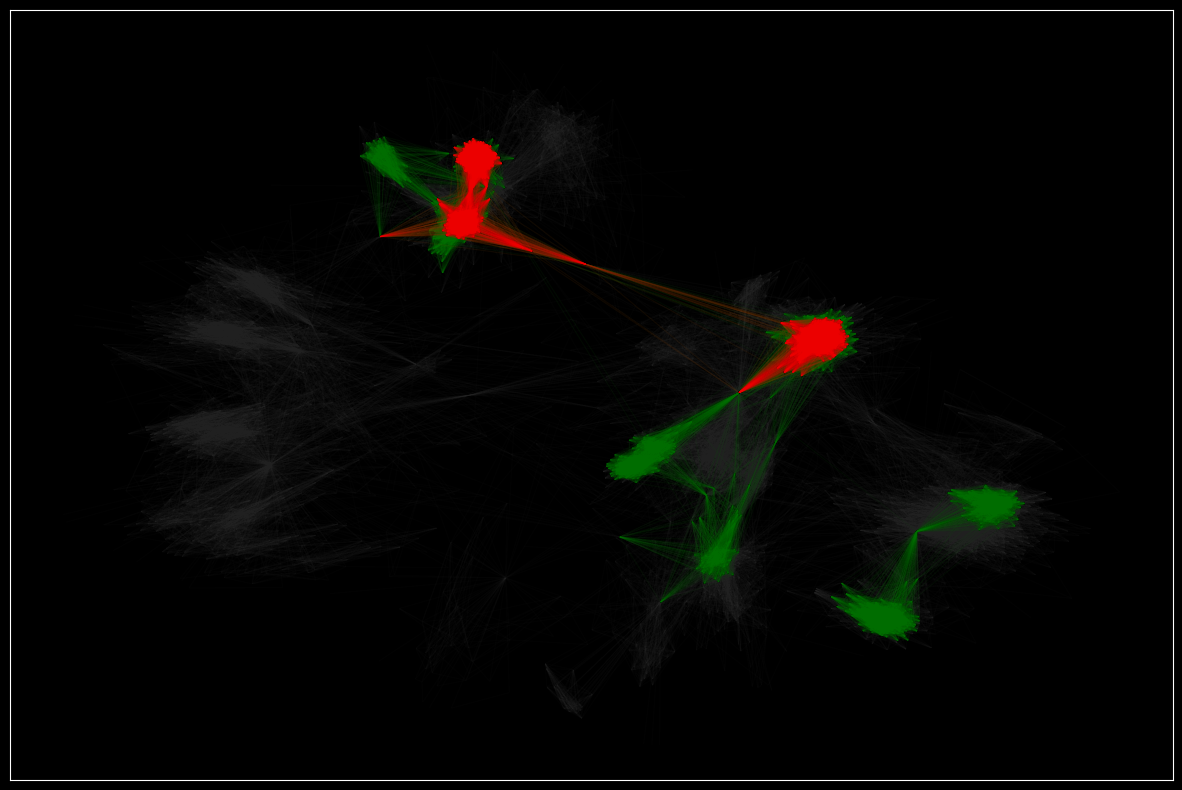

In [29]:
#cell này chạy khoảng 5 phút

# cores with at lest degree 30
G_core_30 = nx.k_core(G_social, 30)
    # similarly, with at least degree 60
G_core_60 = nx.k_core(G_social, 60)
    # Visualize network and k-cores
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.figsize': (15, 10)})
plt.style.use('dark_background')
pos = nx.spring_layout(G_social, k=0.1)
nx.draw_networkx(G_social, pos=pos, node_size=0, edge_color="#333333", alpha=0.05, with_labels=False)
nx.draw_networkx(G_core_30, pos=pos, node_size=0, edge_color="green", alpha=0.05, with_labels=False)
nx.draw_networkx(G_core_60, pos=pos, node_size=0, edge_color="red", alpha=0.05, with_labels=False)
plt.show()

> Câu hỏi nâng cao: tập độc lập (independent set) là một nhóm các đỉnh đôi một không có cạnh nối với nhau, hỏi làm cách nào để có thể chỉ ra được tập độc lập kích thước lớn nhất trong graph Karate?

Tự tìm hiểu thêm một số thư viện về Community Detection trong NetworkX

https://networkx.org/documentation/stable/reference/algorithms/community.html

- **Girvan-Newman algorithm**: The Girvan-Newman algorithm detects communities by progressively removing edges from the original network.
- **Fluid Communities algorithm**: This algorithm is based on the simple idea of fluids interacting in an environment, expanding and pushing each other.
- **Label Propagation algorithm**: Label propagation is a semi-supervised machine learning algorithm that assigns labels to previously unlabeled data points.
- **Clique Percolation algorithm**: The algorithm finds k-clique communities in a graph using the percolation method.
- **Kernighan-Lin algorithm**: This algorithm partitions a network into two sets by iteratively swapping pairs of nodes to reduce the edge cut between sets.

**BÀI TẬP**

**Bài 1.** Từ dữ liệu Zachary's Karate club của thư viện networkx, hãy thực hiện các yêu cầu sau:

a) Hãy tìm kích thước của một nhóm con lớn nhất trong câu lạc bộ sao cho những người trong nhóm đó đôi một không quen nhau (tập độc lập) bằng **cả hai cách**: dùng *maximum_independent_set* hoặc xây dựng graph bù rồi dùng *max_clique*. 

*Gợi ý.* dùng thư viện nx.complement(G).

b) So sánh kết quả giữa *maximum independent set* và *maximal_independent_set*, điểm khác nhau là gì?

c) Hãy thực hiện tìm các cộng đồng trong graph bằng **một trong hai** thuật toán: *greedy_modularity_communities* hoặc *girvan_newman*, trong đó có trực quan, tô màu các cộng đồng bằng các thư viện thích hợp.

In [ ]:
# code tô màu tham khảo (dùng khi có 3 cộng đồng)
import networkx as nx
G = nx.karate_club_graph()
color_map = []
for node in G:
    if node in communities[0]:
        color_map.append('blue')
    elif node in communities[1]:
        color_map.append('green')
    else:
        color_map.append('red')
nx.draw(G, node_color=color_map, with_labels=True)
plt.show()

**Bài 2.** Tìm hiểu ý tưởng của thuật toán Louvain trong tìm kiếm cộng đồng và ứng dụng vào bộ dữ liệu Zachary's Karate club, so sánh với hai thuật toán đã nêu. 

In [ ]:
#CODE HERE